In [1]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 

from torch import nn

In [3]:
matrix = torch.tensor([[7,8],[9,10]])
print(matrix)

tensor([[ 7,  8],
        [ 9, 10]])


In [5]:
matrix.ndim

2

In [7]:
matrix.shape

torch.Size([2, 2])

In [9]:
seed = 1999
m1 = torch.rand(3,2)
m2 = torch.rand(3,2)
m3 = torch.mm(m1,m2.T)
m4 = torch.mm(m1.T,m2)

print(m3)
print(m4)
print(m3.shape,m4.shape)

tensor([[0.2396, 0.5188, 0.1291],
        [0.4280, 0.9345, 0.2304],
        [0.2878, 0.6658, 0.1540]])
tensor([[0.7478, 1.1716],
        [0.3771, 0.5803]])
torch.Size([3, 3]) torch.Size([2, 2])


In [11]:
# Linear Regression

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [13]:
len(X), len(y)

(50, 50)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42)
len(X_train),len(X_test),len(y_train),len(y_test)


(40, 10, 40, 10)

In [17]:
def plot_predictions(train_data = X_train, train_labels = y_train, test_data = X_test, test_labels = y_test, predictions = None):
    plt.figure(figsize = (10,7))
    plt.scatter(train_data, train_labels, c='b', s=4, label = 'Training Data')
    plt.scatter(test_data, test_labels, c='g', s = 4, label = 'Testing Data')

    if predictions is not None:
        plt.scatter(test_data, predictions, c = 'r', s=4,label='Predictions')

    plt.legend(prop={"size":14})

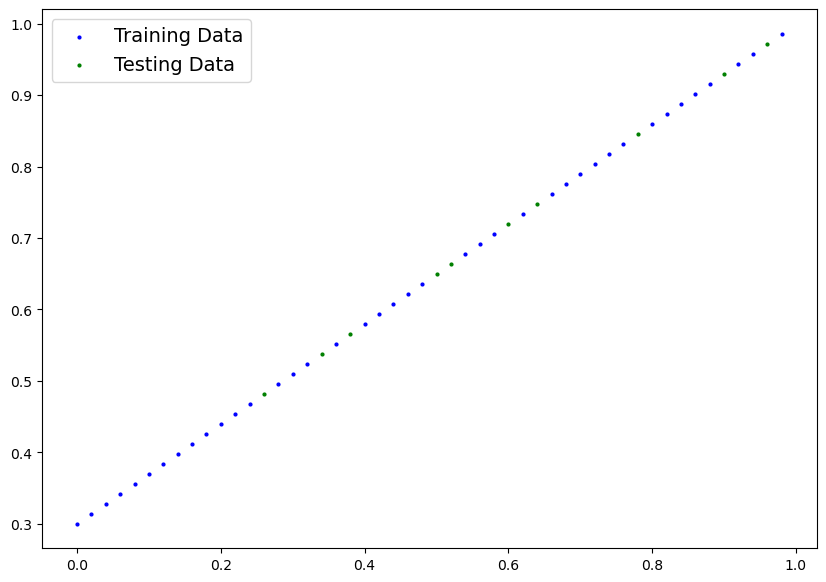

In [19]:
plot_predictions()

In [21]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,requires_grad=True, dtype = torch.float))

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [23]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds


tensor([[0.2163],
        [0.3914],
        [0.3308],
        [0.4318],
        [0.2433],
        [0.4520],
        [0.3039],
        [0.2972],
        [0.3443],
        [0.2568]])

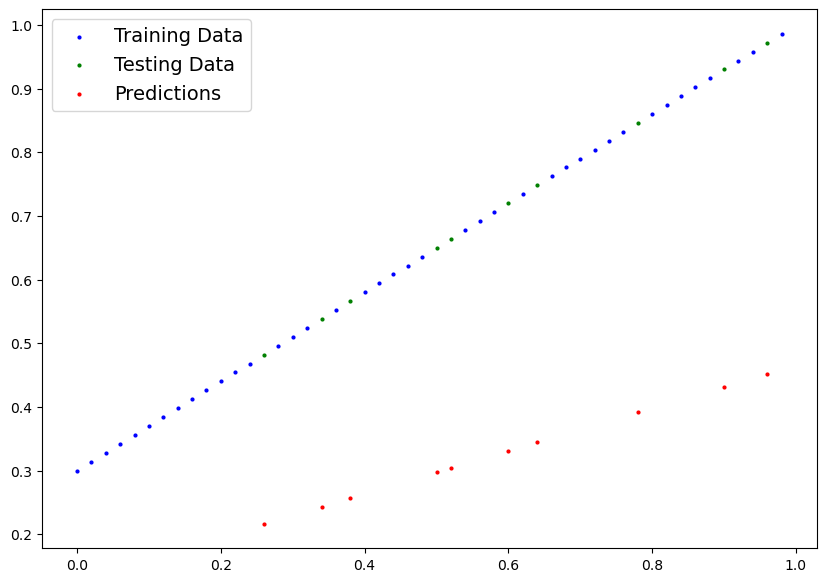

In [25]:
plot_predictions(predictions = y_preds)

In [45]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [35]:
''' TORCH LOSS 
nn.L1Loss - Mean Absolute Error
nn.MSELoss - Mean Squared Error
nn.CrossEntropyLoss - 
nn.NLLLoss - Negative Log Likelihood Loss
nn.GaussianNLLLoss - Gaussian Negative Log Likelihood loss
nn.BCEwithLogitsLoss - Combines Sigmoid Layer with Binary Cross Entropy Loss in a single class'''

' TORCH LOSS \nnn.L1Loss - Mean Absolute Error\nnn.MSELoss - Mean Squared Error\nnn.CrossEntropyLoss - \nnn.NLLLoss - Negative Log Likelihood Loss\nnn.GaussianNLLLoss - Gaussian Negative Log Likelihood loss\nnn.BCEwithLogitsLoss - Combines Sigmoid Layer with Binary Cross Entropy Loss in a single class'

In [39]:
'''TORCH OPTIMIZER Algorithms
*SGD* - Stochastic Gradient Descent
Adadelta - Adadelta Algorithm
Adagrid
*Adam*
AdamW'''

'TORCH OPTIMIZER Algorithms\n*SGD* - Stochastic Gradient Descent\nAdadelta - Adadelta Algorithm\nAdagrid\n*Adam*\nAdamW'

In [47]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [85]:
epochs = 10

for epoch in range(epochs):
    model_0.train()

    y_pred = model_0(X_train)
    loss = loss_fn(y_pred, y_train)
    print(f"Loss - {loss}")
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

model_0.state_dict()    

Loss - 0.16997452080249786


OrderedDict([('weights', tensor([0.4065])), ('bias', tensor([0.2788]))])

In [87]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

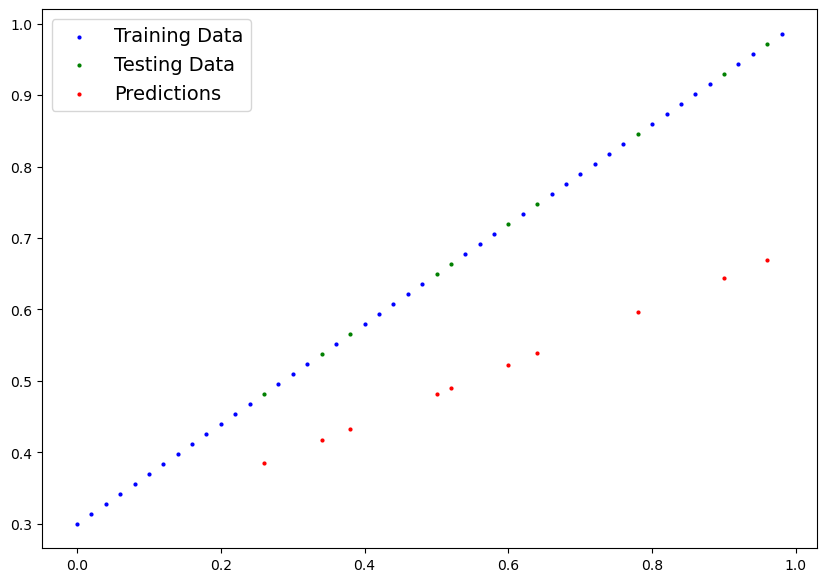

In [89]:
plot_predictions(predictions = y_preds_new)

In [105]:
epochs = 200

# Tracking
epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model_0.train()

    y_pred = model_0(X_train)
    loss = loss_fn(y_pred, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    y_pred = model_0(X_test)
    test_loss = loss_fn(y_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

model_0.state_dict()    

Epoch: 0 | Loss: 0.055295974016189575 | Test Loss: 0.04685746505856514
Epoch: 10 | Loss: 0.04773078113794327 | Test Loss: 0.03634003922343254
Epoch: 20 | Loss: 0.04204443842172623 | Test Loss: 0.03134343773126602
Epoch: 30 | Loss: 0.03644344583153725 | Test Loss: 0.026935016736388206
Epoch: 40 | Loss: 0.030842453241348267 | Test Loss: 0.022526603192090988
Epoch: 50 | Loss: 0.02524144947528839 | Test Loss: 0.018118178471922874
Epoch: 60 | Loss: 0.01964045688509941 | Test Loss: 0.013769281096756458
Epoch: 70 | Loss: 0.014039461500942707 | Test Loss: 0.009508108720183372
Epoch: 80 | Loss: 0.008446384221315384 | Test Loss: 0.005526289343833923
Epoch: 90 | Loss: 0.0028647228609770536 | Test Loss: 0.0017078996170312166
Epoch: 100 | Loss: 0.011139717884361744 | Test Loss: 0.0011160075664520264
Epoch: 110 | Loss: 0.011139717884361744 | Test Loss: 0.0011160075664520264
Epoch: 120 | Loss: 0.011139717884361744 | Test Loss: 0.0011160075664520264
Epoch: 130 | Loss: 0.011139717884361744 | Test Loss:

OrderedDict([('weights', tensor([0.7039])), ('bias', tensor([0.3093]))])

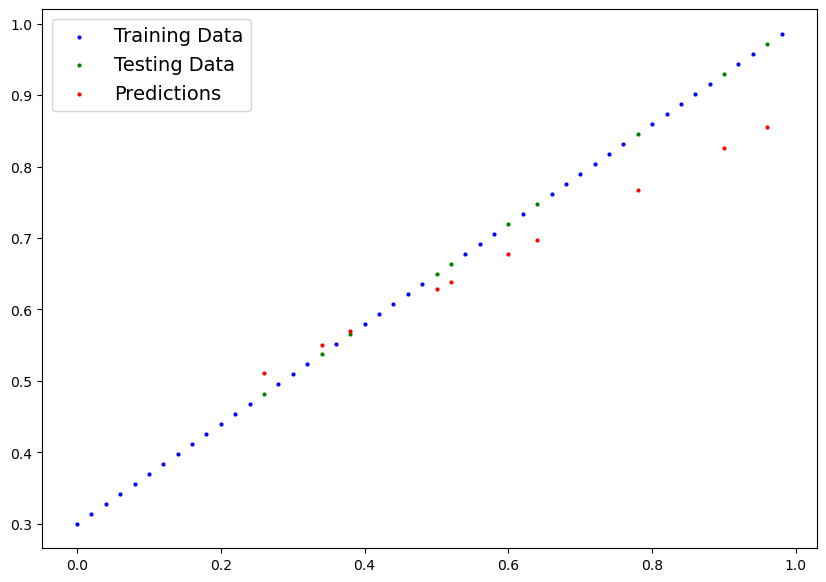

In [103]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)
plot_predictions(predictions = y_preds_new)

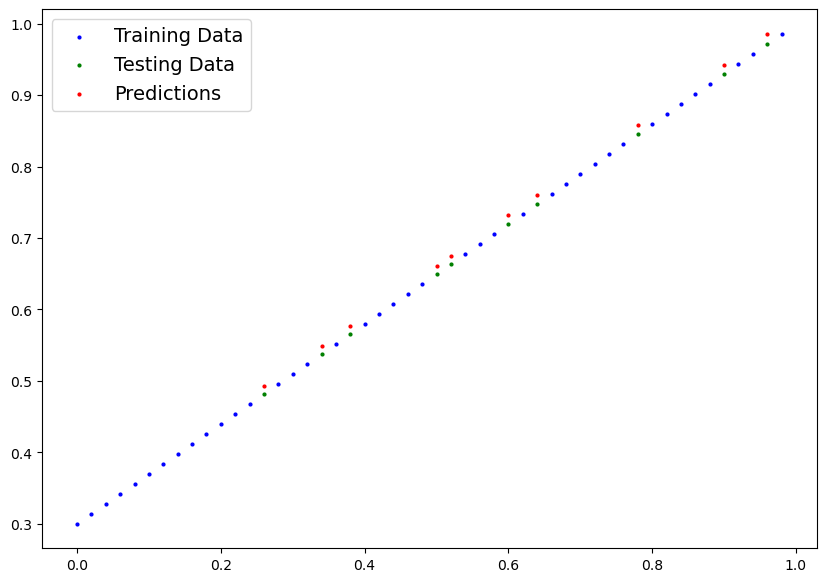

In [107]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)
plot_predictions(predictions = y_preds_new)

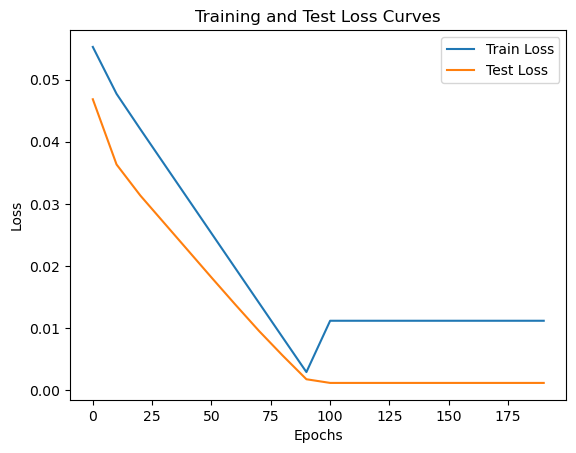

In [117]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label = "Train Loss")
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).numpy()), label = "Test Loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [ ]:
# Saving the Model
# Torch.save() | torch.load() | torch.nn.load_state_dict()

# SAVE
from pathlib import Path

model_path = path('models')
model_path.mkdir(parents=True, exist_ok = True)

model_name = '01_pytorch_workflow_model_0.pth'
model_save_path = model_path / modele_name

print(f"Saving model to: {model_save_path}")
torch.save(mode_0.state_dict(), model_save_path)


# LOAD
# Instatiate a new instance of the model class

loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=model_save_path))